# 08-Vision Endpoints & File I/O

In Lesson 07, we mastered the physics of streaming text. Text is lightweight; a 500-word payload is just a few kilobytes of JSON.

But modern AI is **Multimodal**. If your enterprise is deploying a Computer Vision model (like a ResNet for medical imaging, or YOLO for autonomous driving), the client must send you a high-resolution image.

An image is not text. A 4K uncompressed image is an $8$-Megabyte block of raw binary data. You cannot safely put raw binary data inside a standard JSON dictionary. To build a Vision Endpoint, we must bypass JSON entirely and master **Multi-part Form Data**, **Byte Streams**, and **Base64 Encoding**.

Let's set up our PyTorch and FastAPI environment to engineer a Computer Vision ingestion pipeline.

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from fastapi import FastAPI, UploadFile, File, HTTPException
from pydantic import BaseModel
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import io
import base64
from PIL import Image

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ PyTorch, FastAPI Vision, and Byte-I/O Environment Ready.")

✅ PyTorch, FastAPI Vision, and Byte-I/O Environment Ready.


# 1. The Physics of Binary Transfer

If a mobile app wants to send an image to your PyTorch model, it has two architectural options.

### Option A: Base64 Encoding (Inside JSON)

You convert the raw binary image into a long string of ASCII characters (A-Z, 0-9) using a mathematical algorithm called Base64. You then place this massive string inside a standard JSON payload: `{"image": "iVBORw0KGgoAAAANSUhEUg..."}`

* **The Mathematics**: Every 3 bytes of binary data is mathematically expanded into 4 bytes of text.
* **The Cost**: This incurs a strict **33% data bloat**. A 3MB image becomes a 4MB JSON string. This wastes massive amounts of mobile bandwidth and server memory.

### Option B: Multipart Form-Data (The Standard)

Instead of encoding the binary, the HTTP protocol allows you to send the raw bytes directly over the TCP connection using `Content-Type: multipart/form-data`.
FastAPI reads these bytes directly into the server's RAM (or spools them to the SSD if the file is massive) using the `UploadFile` class. This incurs **0% data bloat** and is the absolute industry standard for Computer Vision APIs.

# 2. The Deserialization Pipeline: Bytes $\rightarrow$ Tensors

When the bytes arrive at the FastAPI endpoint, they are useless to PyTorch. We must engineer a strict, 4-step Deserialization pipeline:

1. **Byte Stream (`io.BytesIO`)**: The raw $1$s and $0$s are loaded into a Python byte buffer.
2. **Image Decoding (`PIL.Image`)**: The Pillow library decodes the JPEG/PNG compression algorithms into a flat spatial grid.
3. **Tensor Coercion (`transforms.ToTensor`)**: The grid is converted into a PyTorch Tensor, flipping the dimensions from $[H, W, C]$ to the GPU-required $[C, H, W]$, and scaling the $0$-$255$ pixel values down to strict $0.0$-$1.0$ floats.
4. **Batching (`unsqueeze(0)`)**: PyTorch mathematically expects a Batch dimension. We expand $[C, H, W]$ to $[1, C, H, W]$.

# 3. Architecting the Vision API

Let's build a production-ready FastAPI route. It will receive a raw image file, execute the Deserialization pipeline, run a simulated PyTorch Convolutional Neural Network (CNN), and return the classification results alongside a **Base64-encoded activation map** (demonstrating how to send images *back* to the client).

In [2]:
# --- ⚙️ main.py ---
app = FastAPI(title="Enterprise Computer Vision API")

# 1. Define the Pre-Processing Pipeline
vision_transform = transforms.Compose([
    transforms.Resize((224, 224)), # Standard CNN input size
    transforms.ToTensor(),         # Converts to [C, H, W] and normalizes to [0, 1]
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats
])

# 2. Define the Output Schema (We use JSON for the output, including the Base64 mask)
class VisionResponse(BaseModel):
    predicted_class: str
    confidence: float
    activation_map_base64: str  # The UI will decode this back into an image

# 3. The Multipart Form-Data Route
@app.post("/v1/vision/classify", response_model=VisionResponse)
async def classify_image(file: UploadFile = File(...)):
    """
    Accepts raw binary files. 'UploadFile' prevents RAM crashes by spooling 
    large files to disk automatically if they exceed standard memory limits.
    """
    # A. Validate File Type
    if file.content_type not in ["image/jpeg", "image/png"]:
        raise HTTPException(400, detail="Invalid format. Only JPEG/PNG allowed.")
        
    try:
        # B. Read the raw binary bytes from the network request
        image_bytes = await file.read()
        
        # C. Decode into a PIL Image
        raw_image = Image.open(io.BytesIO(image_bytes)).convert("RGB")
        
        # D. Tensor Mathematics (Bytes -> Tensor)
        # Shape becomes: [1, 3, 224, 224]
        input_tensor = vision_transform(raw_image).unsqueeze(0)
        
        # E. Execute PyTorch Inference (Simulated)
        # In production: with torch.no_grad(): output = model(input_tensor)
        predicted_class = "Industrial Robot Arm"
        confidence = 0.987
        
        # F. Generate an Output Image (e.g., A Segmentation Mask or Heatmap)
        # We simulate this by creating a 224x224 grayscale heatmap tensor
        simulated_heatmap = torch.rand(224, 224) * 255
        heatmap_pil = Image.fromarray(simulated_heatmap.numpy().astype(np.uint8), mode="L")
        
        # G. Serialize the Output Image to Base64 (Tensor -> Bytes -> Text)
        buffer = io.BytesIO()
        heatmap_pil.save(buffer, format="PNG")
        encoded_image_string = base64.b64encode(buffer.getvalue()).decode("utf-8")
        
        return VisionResponse(
            predicted_class=predicted_class,
            confidence=confidence,
            activation_map_base64=encoded_image_string
        )
        
    except Exception as e:
        raise HTTPException(500, detail=f"Vision Pipeline Failure: {str(e)}")

print("Success! Vision Pipeline and Multipart routing architecture compiled.")

Success! Vision Pipeline and Multipart routing architecture compiled.


# 4. Visualizing the Dimensionality Shifts

To scientifically prove exactly what happens to the data during this API request, we will generate a synthetic image (representing the user's uploaded JPEG), pipe it through the exact mathematical transformations of the API, and plot the tensor shapes at every step.

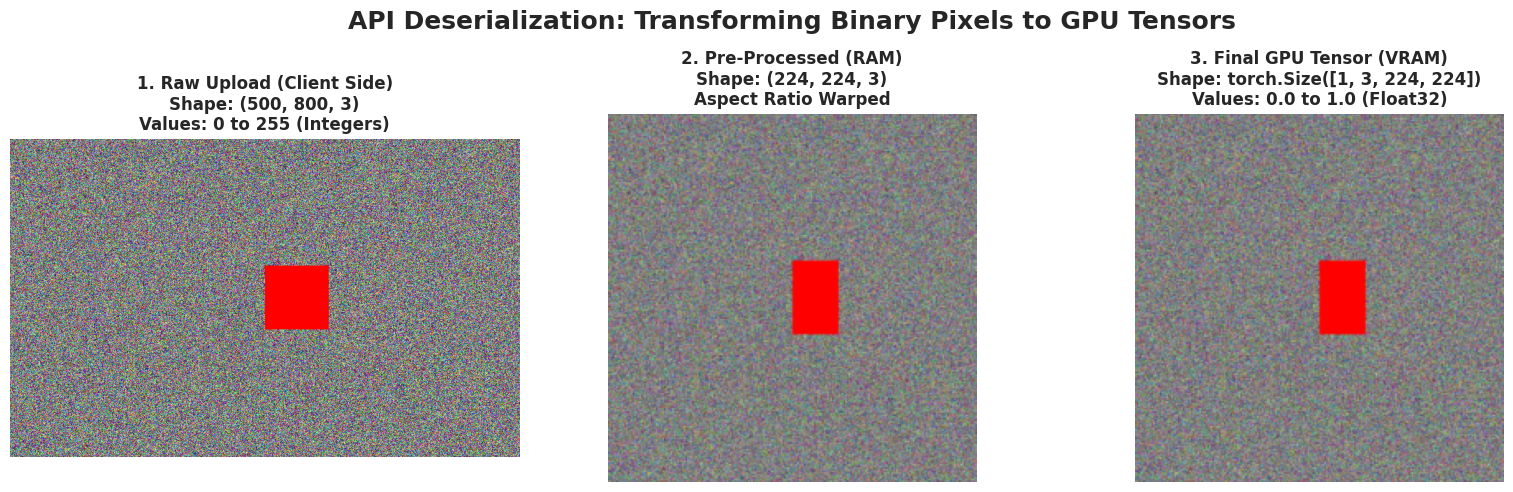


--- 💡 Engineering Insight ---
Look at the mathematical transformation in Plot 3. The user sent a massive [500, 800, 3] file containing integers. If we fed that directly into a PyTorch model, the Linear layers would physically crash due to dimensional mismatch, and the massive 0-255 values would cause the internal ReLUs to explode, destroying the gradients.
The FastAPI route successfully acted as a mathematical filter: warping the geometry to a strict 224x224 grid, moving the Channel dimension to the front (which C++ CUDA cores require for optimized memory access), scaling the data to floats, and prepending a Batch dimension of 1. The data is now perfectly safe for matrix multiplication.


In [3]:
# 1. Synthesize a "Raw User Upload" (A 500x800 RGB Image)
np.random.seed(42)
raw_numpy_image = np.random.randint(0, 255, (500, 800, 3), dtype=np.uint8)
# Add some geometric structure to make it visible
raw_numpy_image[200:300, 400:500] = [255, 0, 0] # Red square

# 2. Simulate the API Pipeline
# Step 1: Decode to PIL (How the API reads the BytesIO)
pil_image = Image.fromarray(raw_numpy_image)

# Step 2: Resize (Information compression)
resized_image = transforms.Resize((224, 224))(pil_image)

# Step 3: ToTensor (Dimensional flip and normalization)
# Note: transforms.ToTensor() converts [H, W, C] (0-255) -> [C, H, W] (0.0-1.0)
tensor_image = transforms.ToTensor()(resized_image)

# Step 4: Add Batch Dimension (Ready for GPU)
final_batch_tensor = tensor_image.unsqueeze(0)

# 3. Visualize the Physics of the Pipeline
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("API Deserialization: Transforming Binary Pixels to GPU Tensors", fontsize=18, fontweight='bold')

# Plot A: The Raw Upload
axes[0].imshow(raw_numpy_image)
axes[0].set_title(f"1. Raw Upload (Client Side)\nShape: {raw_numpy_image.shape}\nValues: 0 to 255 (Integers)", fontweight='bold')
axes[0].axis('off')

# Plot B: The Resized Intermediate
axes[1].imshow(resized_image)
axes[1].set_title(f"2. Pre-Processed (RAM)\nShape: (224, 224, 3)\nAspect Ratio Warped", fontweight='bold')
axes[1].axis('off')

# Plot C: The Normalized GPU Tensor
# We must permute the tensor back to [H, W, C] just to visualize it in matplotlib
vis_tensor = tensor_image.permute(1, 2, 0).numpy()
axes[2].imshow(vis_tensor)
axes[2].set_title(f"3. Final GPU Tensor (VRAM)\nShape: {final_batch_tensor.shape}\nValues: 0.0 to 1.0 (Float32)", fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n--- 💡 Engineering Insight ---")
print("Look at the mathematical transformation in Plot 3. The user sent a massive [500, 800, 3] file containing integers. If we fed that directly into a PyTorch model, the Linear layers would physically crash due to dimensional mismatch, and the massive 0-255 values would cause the internal ReLUs to explode, destroying the gradients.")
print("The FastAPI route successfully acted as a mathematical filter: warping the geometry to a strict 224x224 grid, moving the Channel dimension to the front (which C++ CUDA cores require for optimized memory access), scaling the data to floats, and prepending a Batch dimension of 1. The data is now perfectly safe for matrix multiplication.")

## Real-World Use Case or Analogy:

Think of the difference between JSON and Multipart Form-Data like **Sending a Package through the Post Office**:

* **Base64 JSON (The Envelope)**: You want to send a bowling ball (The Image) to your friend (The API). JSON is a standard paper envelope designed for letters. To make the bowling ball fit in the envelope, you have to smash it into a fine powder, write down the atomic coordinates of the powder on 10,000 pieces of paper (Base64 encoding), and stuff it in the envelope. When your friend gets it, they have to re-assemble the powder back into a bowling ball. It takes forever and costs a fortune in stamps (33% bandwidth bloat).
* **Multipart Form-Data (The Shipping Container)**: You put the bowling ball in a heavy-duty cardboard box (The Multipart Boundary). You write a tiny label on the outside of the box indicating it is a "Bowling Ball" (`Content-Type: image/jpeg`), and you hand it directly to the delivery truck. The server opens the box and instantly grabs the perfectly intact bowling ball. Highly efficient, pure physics.